# 03 · Fraud Modelling, Evaluation & Risk Levels

Models are trained by `python -m src.fraud_model` (training split only). This notebook loads them and evaluates on the **validation** split. The **test** split is used once, at the end, for the selected model.

| Model | Why it is here | Imbalance handling |
|---|---|---|
| Logistic Regression | Interpretable baseline: if it is enough, nothing more complex is justified | `class_weight="balanced"` |
| Random Forest | Non-linear interactions, robust to collinear features | `class_weight="balanced_subsample"` |
| XGBoost | Usually the strongest model on tabular data | `scale_pos_weight` = 337 (negatives / positives) |

**Why no SMOTE?** Class weights already tell each model that a missed fraud costs ~337× a false alarm, without inventing synthetic transactions. SMOTE interpolates between fraud examples, which is harder to justify for transactions and slower on 1.9M rows. If weighting had failed we would have tried it, but it did not fail.

**Hyperparameters** are sensible defaults and deliberately *not tuned*. Tuning against the validation set and then reporting validation results would be optimistic.

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src import evaluation as ev
from src import fraud_model as fm
from src.feature_engineering import FEATURE_SETS

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold"})
MODEL_COLORS = {"logistic_regression": "#2a78d6", "random_forest": "#eb6834", "xgboost": "#1baf7a"}

## 1. Model comparison on validation
Rule baselines are evaluated as binary predictions. `pr_auc` (average precision) is the headline metric: it focuses on the fraud class and is not inflated by the 414K easy negatives the way ROC-AUC is.

In [2]:
comparison = pd.read_json(fm.COMPARISON_PATH)
cols = ["model", "feature_set", "precision", "recall", "f1", "roc_auc", "pr_auc", "fpr", "fnr", "tp", "fp", "fn"]
comparison[cols]

,model,feature_set,precision,recall,f1,roc_auc,pr_auc,fpr,fnr,tp,fp,fn
0,existing_rule_flag,rule,1.0000,0.0024,0.0049,0.5012,0.0054,0.0000,0.9976,3,0,1226
1,balance_drain_rule,rule,1.0000,0.9731,0.9864,0.9866,0.9732,0.0000,0.0269,1196,0,33
2,logistic_regression,full,0.8454,0.9967,0.9149,0.9981,0.9966,0.0005,0.0033,1225,224,4
3,random_forest,full,0.9919,0.9951,0.9935,0.9987,0.9968,0.0000,0.0049,1223,10,6
4,xgboost,full,0.9951,0.9951,0.9951,0.9983,0.9967,0.0000,0.0049,1223,6,6
5,logistic_regression,no_origin_balance,0.0283,0.7665,0.0546,0.9011,0.3496,0.0780,0.2335,942,32312,287
6,random_forest,no_origin_balance,0.3672,0.7022,0.4823,0.9082,0.6902,0.0036,0.2978,863,1487,366
7,xgboost,no_origin_balance,0.0503,0.7648,0.0944,0.9171,0.7010,0.0428,0.2352,940,17754,289


> The precision/recall/F1 columns use a fixed 0.5 threshold. For class-weighted models 0.5 is arbitrary (weighting shifts scores upward), so low precision at 0.5 does not mean the model ranks badly. **PR-AUC is the fair comparison.** Thresholds are chosen properly in section 4.

> **Finding:**
> - **With the `full` feature set, all three models are essentially tied** on validation PR-AUC: 0.9966 (logistic regression), 0.9968 (random forest), 0.9967 (XGBoost). The data is so separable that model choice barely matters.
> - **The one-line balance-drain rule already reaches 0.9731 recall at 100% precision.** XGBoost at 0.5 reaches 0.9951 recall at 0.9951 precision: **27 more frauds caught (1,223 vs 1,196) for 6 false alarms**. That gap is the honest measure of what the model adds.
> - The existing rule flag catches 3 of 1,229 validation frauds (recall 0.24%).
> - **Without origin-balance features** the picture changes completely. PR-AUC is 0.7010 for XGBoost, 0.6902 for random forest and only **0.3496 for logistic regression**. Trees combine the remaining weak signals far better than a linear model can. This is where model choice actually matters.

## 2. Precision–recall curves (validation)

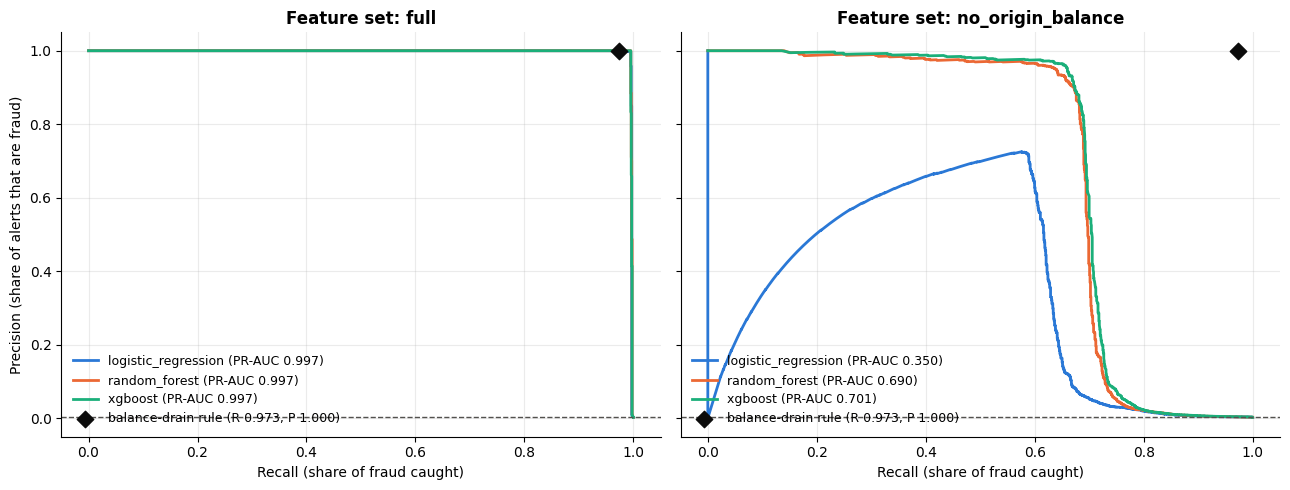

In [3]:
validation = fm.load_split_frame("validation")
y_val = validation["is_fraud"].to_numpy()
scores = {}
for fs in FEATURE_SETS:
    for name in fm.MODEL_ORDER:
        model = joblib.load(fm.model_path(name, fs))
        scores[(name, fs)] = model.predict_proba(validation[FEATURE_SETS[fs]])[:, 1]
rules = fm.rule_baselines(validation)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, fs in zip(axes, FEATURE_SETS):
    for name in fm.MODEL_ORDER:
        p, r, _ = precision_recall_curve(y_val, scores[(name, fs)])
        ap = comparison.query("model == @name and feature_set == @fs")["pr_auc"].iloc[0]
        ax.plot(r, p, color=MODEL_COLORS[name], linewidth=2, label=f"{name} (PR-AUC {ap:.3f})")
    drain = ev.classification_metrics(y_val, rules["balance_drain_rule"])
    ax.scatter([drain["recall"]], [drain["precision"]], marker="D", s=70, color="#0b0b0b", zorder=5,
               label=f"balance-drain rule (R {drain['recall']:.3f}, P {drain['precision']:.3f})")
    ax.axhline(y_val.mean(), color="#52514e", linestyle="--", linewidth=1)
    ax.set_title(f"Feature set: {fs}")
    ax.set_xlabel("Recall (share of fraud caught)")
    ax.legend(loc="lower left", frameon=False, fontsize=9)
axes[0].set_ylabel("Precision (share of alerts that are fraud)")
plt.tight_layout()
plt.show()

> **Finding:**
> - Left panel: the three `full` models overlap almost perfectly, sitting right next to the drain rule (black diamond).
> - Right panel: the tree models hold about 97% precision up to roughly 65% recall, then collapse. Around a third of fraud is indistinguishable from legitimate traffic without origin-balance information. Logistic regression never exceeds about 72% precision.
> - The drain rule is drawn on the right panel for reference only. It uses origin-balance information that panel's models do not have.

## 3. Selected model
Selection rule (`fm.select_model`): best validation PR-AUC within the `full` set; differences < 0.001 count as ties, which are broken by F1 at 0.5.

In [4]:
bundle = fm.load_bundle()
print("Deployed:", bundle["version"])
deployed_scores = scores[(bundle["model_name"], bundle["feature_set"])]

Deployed: fraud-xgboost-full-20261001


## 4. Threshold analysis (validation)

**What the errors cost:**
- **False positive** = a legitimate transaction flagged as fraud: an analyst's time, a delayed payment, an annoyed customer.
- **False negative** = a fraudulent transaction classified as legitimate: the money is lost.

There is no universally "optimal" threshold; it depends on how a business weighs these costs. The tables show the trade-off for the deployed model and for the harder `no_origin_balance` XGBoost.

In [5]:
print("Deployed model (xgboost, full):")
display(ev.threshold_table(y_val, deployed_scores))
print("XGBoost, no_origin_balance:")
display(ev.threshold_table(y_val, scores[("xgboost", "no_origin_balance")]))

Deployed model (xgboost, full):


,threshold,precision,recall,f1,fpr,fnr,tp,fp,fn,alerts
0,0.3000,0.9951,0.9951,0.9951,0.0000,0.0049,1223,6,6,1229
1,0.4000,0.9951,0.9951,0.9951,0.0000,0.0049,1223,6,6,1229
2,0.5000,0.9951,0.9951,0.9951,0.0000,0.0049,1223,6,6,1229
3,0.6000,0.9951,0.9951,0.9951,0.0000,0.0049,1223,6,6,1229
4,0.7000,0.9951,0.9951,0.9951,0.0000,0.0049,1223,6,6,1229


XGBoost, no_origin_balance:


,threshold,precision,recall,f1,fpr,fnr,tp,fp,fn,alerts
0,0.3000,0.0157,0.8275,0.0308,0.1540,0.1725,1017,63817,212,64834
1,0.4000,0.0273,0.7917,0.0529,0.0835,0.2083,973,34605,256,35578
2,0.5000,0.0503,0.7648,0.0944,0.0428,0.2352,940,17754,289,18694
3,0.6000,0.1121,0.7323,0.1944,0.0172,0.2677,900,7131,329,8031
4,0.7000,0.2246,0.7209,0.3425,0.0074,0.2791,886,3059,343,3945


> **Finding:**
> - **For the deployed model, thresholds 0.30–0.70 give identical results** (1,223 TP, 6 FP, 6 FN). Its scores are almost all near 0 or near 1, so moving the threshold within this range changes nothing. 0.5 is not "optimal"; it just doesn't matter here.
> - **For the `no_origin_balance` XGBoost the threshold matters enormously.** Going from 0.30 to 0.70 cuts alerts from 64,834 to 3,945 (precision 1.6% to 22.5%), while recall falls only from 82.8% to 72.1%.
> - That is the realistic trade-off a fraud team would face: each step trades analyst workload (false positives) against lost money (false negatives).

## 5. Risk levels: LOW / MEDIUM / HIGH

Boundaries come from **business targets applied to validation data** (`ev.choose_risk_boundaries`), not from hand-picked numbers:
- **HIGH:** lowest score at which ≥ 99% of alerts are fraud, so they are safe to act on automatically (hold funds).
- **MEDIUM:** lowest score at which alert precision is still ≥ 90%: the analyst review queue, catching as much fraud as possible while keeping the queue at least 90% fraud.
- **LOW:** everything else.

In [6]:
boundaries = bundle["risk_boundaries"]
print({k: v for k, v in boundaries.items()})
display(ev.risk_level_table(y_val, deployed_scores, boundaries))

{'medium': 0.0013959595235064626, 'high': 0.13806141912937164, 'targets': {'high_min_precision': 0.99, 'medium_min_precision': 0.9}}


,transactions,fraud,fraud_rate_pct,share_of_all_fraud_pct
risk_level,,,,
LOW,414201,6,0.0010,0.4900
MEDIUM,123,0,0.0000,0.0000
HIGH,1235,1223,99.0280,99.5100


### Score distribution: why the bands look the way they do

In [7]:
display(ev.calibration_table(y_val, deployed_scores, bins=(0, 0.001, 0.01, 0.1, 0.5, 0.9, 0.99, 1.0001)))

,transactions,mean_score,observed_fraud_rate
bin,,,
"[0.0, 0.001)",414160,0.0000,0.0000
"[0.001, 0.01)",130,0.0028,0.0000
"[0.01, 0.1)",32,0.0340,0.0000
"[0.1, 0.5)",8,0.1495,0.0000
"[0.9, 0.99)",4,0.9724,0.0000
"[0.99, 1.0)",1225,1.0000,0.9984


> **Finding:**
> - The boundaries come out at **MEDIUM ≥ 0.0014** and **HIGH ≥ 0.1381**.
> - On validation: HIGH holds 1,235 transactions, 99.03% of them fraud, capturing 99.51% of all fraud. MEDIUM holds 123 transactions with **0 fraud**. LOW holds 414,201 transactions with 6 frauds.
> - **The MEDIUM band is nearly empty of fraud** because the model's scores are bimodal: 414,160 validation transactions score below 0.001 and 1,225 score at or above 0.99. In the grey zone between them (174 transactions scoring 0.001 to 0.99), none are fraud.
> - **Scores are not calibrated probabilities.** Class weighting (scale_pos_weight = 337) inflates them: 4 legitimate transactions score 0.90–0.99 and none of those 12 mid-range transactions is fraud. The API therefore returns the score together with the risk level, and the risk level is the field to act on.

## 6. Final evaluation on the test split (used once)

In [8]:
test = fm.load_split_frame("test")
y_test = test["is_fraud"].to_numpy()
test_scores = bundle["model"].predict_proba(test[bundle["features"]])[:, 1]
test_rules = fm.rule_baselines(test)

final = pd.DataFrame([
    {"system": "existing rule flag", **ev.classification_metrics(y_test, test_rules["existing_rule_flag"])},
    {"system": "balance-drain rule", **ev.classification_metrics(y_test, test_rules["balance_drain_rule"])},
    {"system": "model @ MEDIUM boundary", **ev.classification_metrics(y_test, test_scores, boundaries["medium"])},
    {"system": "model @ HIGH boundary", **ev.classification_metrics(y_test, test_scores, boundaries["high"])},
])
display(final[["system", "precision", "recall", "f1", "fpr", "fnr", "tp", "fp", "fn", "alerts"]])
display(ev.risk_level_table(y_test, test_scores, boundaries))

,system,precision,recall,f1,fpr,fnr,tp,fp,fn,alerts
0,existing rule flag,1.0000,0.0008,0.0016,0.0000,0.9992,1,0,1229,1
1,balance-drain rule,1.0000,0.9756,0.9877,0.0000,0.0244,1200,0,30,1200
2,model @ MEDIUM boundary,0.9096,0.9984,0.9519,0.0003,0.0016,1228,122,2,1350
3,model @ HIGH boundary,0.9935,0.9967,0.9951,0.0000,0.0033,1226,8,4,1234


,transactions,fraud,fraud_rate_pct,share_of_all_fraud_pct
risk_level,,,,
LOW,414209,2,0.0000,0.1600
MEDIUM,116,2,1.7240,0.1600
HIGH,1234,1226,99.3520,99.6700


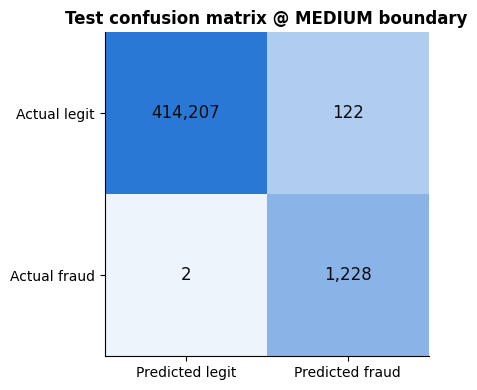

In [9]:
import matplotlib.colors as mcolors
cm = np.array([[final.loc[2, "tn"], final.loc[2, "fp"]], [final.loc[2, "fn"], final.loc[2, "tp"]]])
fig, ax = plt.subplots(figsize=(4.8, 4))
ax.imshow(np.log10(cm + 1), cmap=mcolors.LinearSegmentedColormap.from_list("b", ["#eef4fc", "#2a78d6"]))
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=12, color="#0b0b0b")
ax.set_xticks([0, 1], ["Predicted legit", "Predicted fraud"]); ax.set_yticks([0, 1], ["Actual legit", "Actual fraud"])
ax.grid(False); ax.set_title("Test confusion matrix @ MEDIUM boundary")
plt.tight_layout(); plt.show()

> **Finding (test split, evaluated once):**
> - **At the MEDIUM boundary** (the review queue): recall **99.84%** (1,228 of 1,230 frauds), precision **90.96%**, 122 false positives among 414,329 legitimate transactions (FPR 0.03%), 2 missed frauds.
> - **At the HIGH boundary:** recall 99.67%, precision 99.35%.
> - On test, the MEDIUM band did catch 2 frauds out of 116 transactions (1.72%), which it never did on validation.
> - **Against the baselines on test:** the drain rule catches 1,200 frauds (97.56%) with no false alarms; the existing rule flag catches 1. The model at HIGH catches **26 more frauds than the drain rule, at the cost of 8 false alarms**.
> - **Validation and test agree closely**, so the selection and boundaries were not overfitted to validation.

## Summary

| Decision | Reason |
|---|---|
| Deploy **XGBoost, `full` features** | Tied best PR-AUC (0.9967); best F1 at 0.5; fast to train (seconds) and explain (exact TreeExplainer) |
| Report the **drain rule** next to every model | It reaches 97.3–97.6% recall alone; the model's real contribution is about +2 points of recall |
| **Class weights**, not SMOTE | Worked well; no synthetic transactions needed |
| **Precision-based risk boundaries** chosen on validation | HIGH ≥ 99% precision (auto-hold), MEDIUM ≥ 90% (review queue); boundaries come from data, not chosen by hand |
| Treat scores as **rankings, not probabilities** | Class weighting inflates scores; risk level is the field to act on |

**Most important caveat:** the strong results depend on a simulator artefact. The `no_origin_balance` results (PR-AUC 0.70) are a better guide to how hard real fraud detection is.